In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Dados para download
banco_dados = 'https://docs.google.com/spreadsheets/d/1r0_Vs5QX1ef5X1MZCbDg8kcqm-my3rSn/edit?usp=sharing&ouid=108903987275959757465&rtpof=true&sd=true'

print(banco_dados)


https://docs.google.com/spreadsheets/d/1r0_Vs5QX1ef5X1MZCbDg8kcqm-my3rSn/edit?usp=sharing&ouid=108903987275959757465&rtpof=true&sd=true


In [3]:
df = pd.read_excel('Vase_004 - Magalu - Sem Resolução.xlsx')
df

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
0,2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740
1,2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058
2,2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999
3,2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217
4,2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723
...,...,...,...,...,...,...,...
242,2021-12-23,6.340000,5.990000,6.220000,6.200000,97106100,6.200000
243,2021-12-27,6.780000,6.230000,6.230000,6.780000,124279800,6.780000
244,2021-12-28,6.960000,6.640000,6.790000,6.830000,165573900,6.830000
245,2021-12-29,6.900000,6.700000,6.840000,6.760000,79247400,6.760000


In [4]:
df.shape

(247, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        247 non-null    datetime64[ns]
 1   Maior       247 non-null    float64       
 2   Menor       247 non-null    float64       
 3   Abertura    247 non-null    float64       
 4   Fechamento  247 non-null    float64       
 5   Volume      247 non-null    int64         
 6   Adj Close   247 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.6 KB


In [8]:
df.describe()

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
count,247,247.000000,247.000000,247.000000,247.000000,2.470000e+02,247.000000
mean,2021-07-02 21:28:25.263158016,18.977530,18.205668,18.629717,18.549555,4.536056e+07,18.541389
min,2021-01-04 00:00:00,6.200000,5.620000,5.710000,5.740000,8.716100e+06,5.740000
25%,2021-04-05 12:00:00,15.010000,14.275000,14.705000,14.555000,2.285200e+07,14.555000
50%,2021-07-02 00:00:00,20.650000,19.930000,20.280001,20.270000,3.130900e+07,20.255312
75%,2021-09-29 12:00:00,22.595000,21.985001,22.375000,22.200001,4.742785e+07,22.183912
max,2021-12-30 00:00:00,27.070000,25.900000,26.250000,26.240000,2.578313e+08,26.220984
std,NaN,5.632712,5.567061,5.602659,5.637050,4.082594e+07,5.631316


In [9]:
#Séries temporais
dados = df.set_index('Data')
dados.head(3)

,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
Data,,,,,,
2021-01-04,25.58,24.870001,25.26,25.200001,25706100,25.181740
2021-01-05,25.18,24.340000,25.10,24.760000,25431900,24.742058
2021-01-06,24.66,23.420000,24.65,23.459999,51799000,23.442999


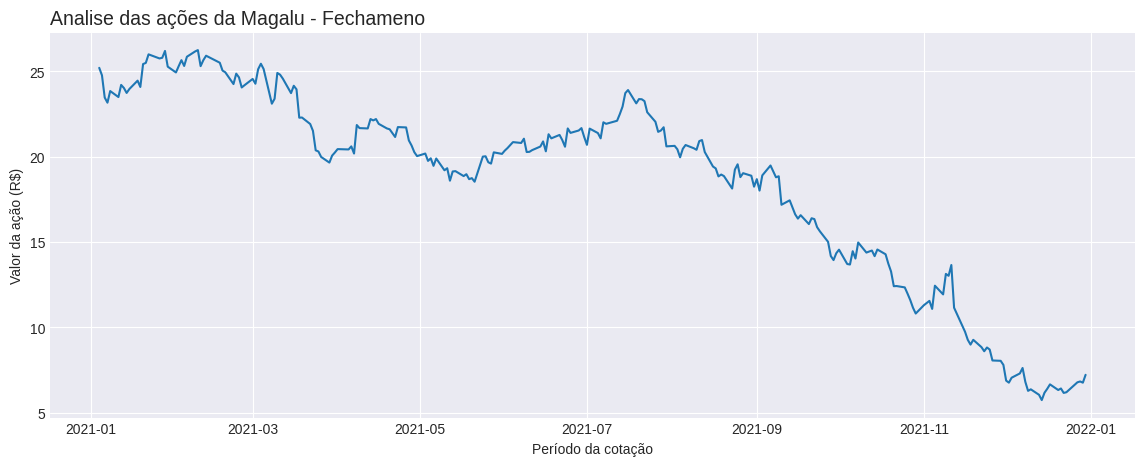

In [21]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14,5))
plt.title('Analise das ações da Magalu - Fechameno', fontsize=14, loc='left')
plt.plot(dados.index, dados['Fechamento'])
plt.xlabel('Período da cotação')
plt.ylabel('Valor da ação (R$)');

In [22]:
df.tail()

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
242,2021-12-23,6.34,5.99,6.22,6.20,97106100,6.20
243,2021-12-27,6.78,6.23,6.23,6.78,124279800,6.78
244,2021-12-28,6.96,6.64,6.79,6.83,165573900,6.83
245,2021-12-29,6.90,6.70,6.84,6.76,79247400,6.76
246,2021-12-30,7.41,6.77,6.80,7.22,180329400,7.22


In [25]:
media_movel = dados['Fechamento'].rolling(5).mean()
media_movel

Data
2021-01-04       NaN
2021-01-05       NaN
2021-01-06       NaN
2021-01-07       NaN
2021-01-08    24.084
               ...  
2021-12-23     6.354
2021-12-27     6.378
2021-12-28     6.478
2021-12-29     6.546
2021-12-30     6.758
Name: Fechamento, Length: 247, dtype: float64

In [27]:
media_tendencia = dados['Fechamento'].rolling(30).mean()
media_tendencia

Data
2021-01-04         NaN
2021-01-05         NaN
2021-01-06         NaN
2021-01-07         NaN
2021-01-08         NaN
                ...   
2021-12-23    7.737667
2021-12-27    7.508667
2021-12-28    7.364667
2021-12-29    7.265333
2021-12-30    7.197000
Name: Fechamento, Length: 247, dtype: float64

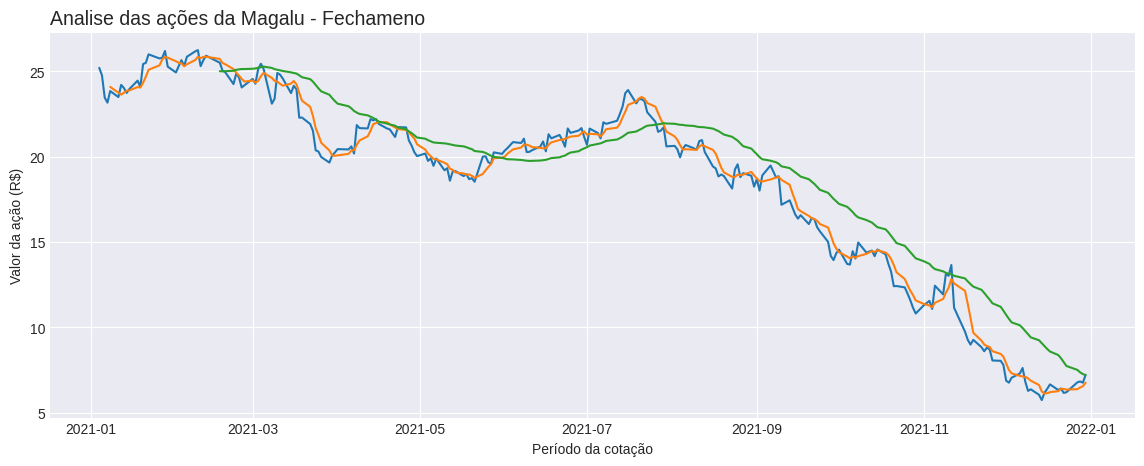

In [29]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(14,5))
plt.title('Analise das ações da Magalu - Fechameno', fontsize=14, loc='left')
plt.plot(dados.index, dados['Fechamento'])
plt.plot(dados.index, media_movel)
plt.plot(dados.index, media_tendencia)
plt.xlabel('Período da cotação')
plt.ylabel('Valor da ação (R$)');

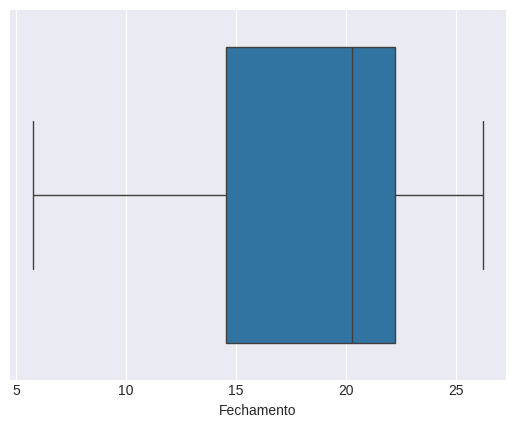

In [30]:
sns.boxplot(data=dados, x='Fechamento');

In [33]:
#Boxplot mensal
df['Mes'] = df['Data'].dt.month
df

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close,Mes
0,2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740,1
1,2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058,1
2,2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999,1
3,2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217,1
4,2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723,1
...,...,...,...,...,...,...,...,...
242,2021-12-23,6.340000,5.990000,6.220000,6.200000,97106100,6.200000,12
243,2021-12-27,6.780000,6.230000,6.230000,6.780000,124279800,6.780000,12
244,2021-12-28,6.960000,6.640000,6.790000,6.830000,165573900,6.830000,12
245,2021-12-29,6.900000,6.700000,6.840000,6.760000,79247400,6.760000,12


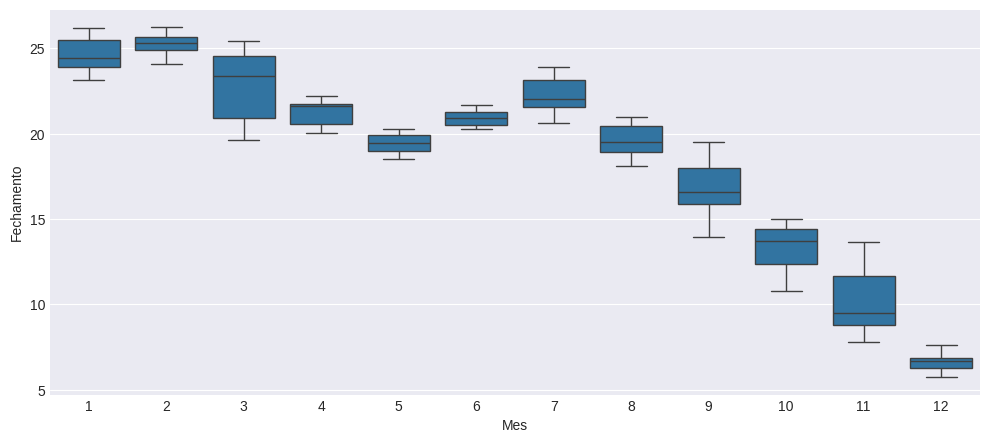

In [34]:
plt.figure(figsize= (12,5))
sns.boxplot(data=df, x='Mes', y='Fechamento');

In [35]:
df.groupby(['Mes']).describe()['Fechamento']

,count,mean,min,25%,50%,75%,max,std
Mes,,,,,,,,
1,19.0,24.644737,23.160000,23.900000,24.450001,25.455000,26.190001,0.960280
2,18.0,25.208889,24.049999,24.877501,25.299999,25.650000,26.240000,0.656021
3,23.0,22.855217,19.650000,20.940001,23.389999,24.559999,25.440001,1.976698
4,20.0,21.249000,20.030001,20.560000,21.625000,21.760000,22.200001,0.735297
5,21.0,19.430476,18.530001,18.969999,19.459999,19.900000,20.250000,0.564973
6,21.0,20.898095,20.270000,20.500000,20.889999,21.270000,21.670000,0.463116
7,21.0,22.232857,20.600000,21.530001,22.040001,23.120001,23.900000,0.977574
8,22.0,19.656818,18.129999,18.897500,19.485000,20.452499,20.969999,0.885827
9,21.0,16.746191,13.940000,15.870000,16.570000,18.010000,19.480000,1.628581


In [39]:
grafico = go.Figure(
    data=[
        go.Candlestick(
            x = dados.index,
            open = dados['Abertura'],
            high = dados['Maior'],
            low = dados['Menor'],
            close = dados['Fechamento']
        )
    ]
)
grafico.update_layout(xaxis_rangeslider_visible=False)
grafico.show()